In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

from pathlib import Path # to define dir path
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import PIL
from PIL import Image

import argparse

from tqdm.auto import tqdm

from functools import partial

import torch
import torch.nn as nn
from torch.nn import init
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import datasets
from datasets import Dataset

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Python Class that will save the best model while training

# Function to Save the Last Epoch’s Model and the Loss & Accuracy Graphs

# We will call this function after the training iterations for all the epochs are complete.

# The final helper function is for saving the loss and accuracy graphs for training and validation.

In [4]:
class SaveBestModel:
    """
    Class to save the best model while training. If the current epoch's 
    validation loss is less than the previous least less, then save the
    model state.
    """
    def __init__(
        self, best_valid_loss=float('inf'), 
    ):
        self.best_valid_loss = best_valid_loss
        
        
        
    def __call__(
        self, current_valid_loss, 
        epoch, model, optimizer, criterion, out_dir
    ):
        if current_valid_loss < self.best_valid_loss:
            self.best_valid_loss = current_valid_loss
            print(f"\nBest validation loss: {self.best_valid_loss}")
            print(f"\nSaving best model for epoch: {epoch+1}\n")
            torch.save({
                'epoch': epoch+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': criterion,
                }, out_dir/'best_model.pth')

In [5]:
def save_model(epochs, model, optimizer, criterion, out_dir):
        """
        Function to save the trained model to disk.
        """
        print(f"Saving final model...")
        torch.save({
                    'epoch': epochs,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': criterion,
                    }, out_dir/'final_model.pth')
    
def save_plots(train_acc, valid_acc, train_loss, valid_loss, out_dir):
    """
    Function to save the loss and accuracy plots to disk.
    """
        # accuracy plots
    plt.figure(figsize=(10, 7))
    plt.plot(
        train_acc, color='green', linestyle='-', 
        label='train accuracy'
    )
    plt.plot(
        valid_acc, color='blue', linestyle='-', 
        label='validataion accuracy'
    )
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(out_dir/'accuracy.pdf', dpi = 600, format='pdf', bbox_inches='tight')
    
    # loss plots
    plt.figure(figsize=(10, 7))
    plt.plot(
        train_loss, color='orange', linestyle='-', 
        label='train loss'
    )
    plt.plot(
        valid_loss, color='red', linestyle='-', 
        label='validataion loss'
    )
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(out_dir/'loss.pdf', dpi = 600, format='pdf', bbox_inches='tight')
    

In [6]:
def create_data_loaders(dataset_train, dataset_valid):
    """
    Function to build the data loaders.
    Parameters:
    :param dataset_train: The training dataset.
    :param dataset_valid: The validation dataset.
    :param dataset_test: The test dataset.
    """
    train_loader = DataLoader(
        dataset_train, batch_size=64, shuffle=True, num_workers=2
    )
    valid_loader = DataLoader(
        dataset_valid, batch_size=1, shuffle=False, num_workers=2
    )
    return train_loader, valid_loader

In [7]:
class LayerNorm(nn.Module):
    def __init__(self, dummy, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.mult = nn.Parameter(tensor(1.))
        self.add  = nn.Parameter(tensor(0.))

    def forward(self, x):
        m = x.mean((1,2,3), keepdim=True)
        v = x.var ((1,2,3), keepdim=True)
        x = (x-m) / ((v+self.eps).sqrt())
        return x*self.mult + self.add

In [8]:
def init_weights(m, leaky=0.):
    if isinstance(m, (nn.Conv1d,nn.Conv2d,nn.Conv3d)): init.kaiming_normal_(m.weight, a=leaky)

In [9]:
iw = partial(init_weights, leaky=0.1)

In [10]:
class GlobalAvgPool(nn.Module):
    def forward(self, x): return x.mean((-2,-1))

In [11]:
def conv(ni, nf, ks=3, stride=2, act=nn.ReLU, norm=None, bias=None):
    if bias is None: bias = not isinstance(norm, (nn.BatchNorm1d,nn.BatchNorm2d,nn.BatchNorm3d))
    layers = [nn.Conv2d(ni, nf, stride=stride, kernel_size=ks, padding=ks//2, bias=bias)]
    if norm: layers.append(norm(nf))
    if act: layers.append(act())
    return nn.Sequential(*layers)

In [12]:
class CustomFCLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout_p=0.8):
        super(CustomFCLayer, self).__init__()
        self.dropout = nn.Dropout(dropout_p)
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.bn = nn.BatchNorm1d(out_features)
        self.name = 'fc'   # Set the name of the last layer as 'fc'

    def forward(self, x):
        x = self.dropout(x)
        x = self.linear(x)
        x = self.bn(x)
        return x

In [13]:
def build_model_cnn(n_classes, act=nn.ReLU, nfs=(8, 16, 32, 64, 128), norm=nn.BatchNorm2d, drop=0.8):
    layers = [conv(3, 8, stride=1, act=act, norm=norm)]  # nn.Dropout2d(0.0)
    layers += [conv(nfs[i], nfs[i + 1], act=act, norm=norm) for i in range(len(nfs) - 1)]
    layers += [GlobalAvgPool()]
    layers += [CustomFCLayer(nfs[-1], n_classes, dropout_p=drop)]
    return nn.Sequential(*layers).to(device)
     

In [14]:
def build_model_res(pretrained=True, fine_tune=True, num_classes=1):
    """
    Function to build the neural network model. Returns the final model.
    Parameters
    :param pretrained (bool): Whether to load the pre-trained weights or not.
    :param fine_tune (bool): Whether to train the hidden layers or not.
    :param num_classes (int): Number of classes in the dataset. 
    """
    if pretrained:
        print('[INFO]: Loading pre-trained weights')
    elif not pretrained:
        print('[INFO]: Not loading pre-trained weights')
    model = models.resnet18(pretrained=pretrained)
    if fine_tune:
        print('[INFO]: Fine-tuning all layers...')
        for params in model.parameters():
            params.requires_grad = True
    elif not fine_tune:
        print('[INFO]: Freezing hidden layers...')
        for params in model.parameters():
            params.requires_grad = False
            
    # change the final classification head, it is trainable
    model.fc = CustomFCLayer(512, num_classes, dropout_p=0.8)
    return model

In [15]:
# training
def train(model, trainloader, optimizer, criterion, scheduler):
    model.train()
    print('Training')
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    for i, data in tqdm(enumerate(trainloader), total=len(trainloader)):
        counter += 1
        image, labels = data
        image = image.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        # forward pass
        outputs = model(image)
        # calculate the loss
        loss = criterion(outputs, labels)
        train_running_loss += loss.item()
        # calculate the accuracy
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == labels).sum().item()
        # backpropagation
        loss.backward()
        # update the optimizer parameters
        optimizer.step()
        scheduler.step()
    
    # loss and accuracy for the complete epoch
    epoch_loss = train_running_loss / counter
    epoch_acc = 100. * (train_running_correct / len(trainloader.dataset))
    return epoch_loss, epoch_acc

In [16]:
# validation
def validate(model, testloader, criterion):
    model.eval()
    print('Validation')
    valid_running_loss = 0.0
    valid_running_correct = 0
    counter = 0
    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1
            
            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # forward pass
            outputs = model(image)
            # calculate the loss
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()
            # calculate the accuracy
            _, preds = torch.max(outputs.data, 1)
            valid_running_correct += (preds == labels).sum().item()
        
    # loss and accuracy for the complete epoch
    epoch_loss = valid_running_loss / counter
    epoch_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return epoch_loss, epoch_acc

In [17]:
def test(model, testloader):
    """
    Function to test the model
    """
    # set model to evaluation mode
    model.eval()
    print('Testing')
    valid_running_correct = 0
    counter = 0
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for i, data in tqdm(enumerate(testloader), total=len(testloader)):
            counter += 1
            
            image, labels = data
            image = image.to(device)
            labels = labels.to(device)
            # forward pass
            outputs = model(image)
            # calculate the accuracy
            _, preds = torch.max(outputs.data, 1)
            all_predictions.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())
            
            valid_running_correct += (preds == labels).sum().item()
        
    # loss and accuracy for the complete epoch
    final_acc = 100. * (valid_running_correct / len(testloader.dataset))
    return final_acc, all_predictions, all_targets

In [18]:
# test the last epoch saved model
def test_last_model(model, checkpoint, test_loader):
    print('Loading last epoch saved model weights...')
    model.load_state_dict(checkpoint['model_state_dict'])
    test_acc,ap, at = test(model, test_loader)
    return test_acc,ap, at
# test the best epoch saved model
def test_best_model(model, checkpoint, test_loader):
    print('Loading best epoch saved model weights...')
    model.load_state_dict(checkpoint['model_state_dict'])
    test_acc, ap, at = test(model, test_loader)
    return test_acc,ap, at

In [19]:
def load_pretrained_model(path_to_model, n_classes=2, CNN = True): # Assuming the original model has 2 output classes
    if CNN:
        model = build_model_cnn(n_classes)
    else:
        model = build_model_res(pretrained=False, fine_tune=False, num_classes=n_classes)
    checkpoint = torch.load(path_to_model)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

In [20]:
def replace_last_layers(model, n_classes=3, CNN = True):
    if CNN:
        in_features = model[-1].linear.in_features
        model[-1] = CustomFCLayer(in_features, n_classes, dropout_p=0.8)
    else:
        in_features = model.fc.linear.in_features
        model.fc = CustomFCLayer(in_features, n_classes, dropout_p=0.8)
        
    return model

In [21]:
class SpecImageGenerator28(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        #self.xmean = xmean
        #self.xstd = xstd

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # Load audio tensor from file path
        image_tensor = (TF.to_tensor(Image.open(self.dataset[index]['image']).resize((28,28)))-0.5)
        mean = 0.28
        std = 0.35
        image_tensor = (image_tensor-mean)/std
        cls_voc = self.dataset[index]['classes']
        # Return the images and labels
        return image_tensor[:3,:,:], torch.tensor(cls_voc)

In [22]:
class SpecImageGenerator224(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        #self.xmean = xmean
        #self.xstd = xstd

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # Load audio tensor from file path
        image_tensor = (TF.to_tensor(Image.open(self.dataset[index]['image']).resize((224,224)))-0.5)
        mean = 0.28
        std = 0.35
        image_tensor = (image_tensor-mean)/std
        cls_voc = self.dataset[index]['classes']
        # Return the images and labels
        return image_tensor[:3,:,:], torch.tensor(cls_voc)

In [23]:
def plot_confusion_matrix(y_true, y_preds, labels, out_dir, normalize = None):
    cm = confusion_matrix(y_true, y_preds, normalize = normalize)
    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
    disp.plot(cmap = 'Blues', values_format = '.2f', ax = ax, colorbar = False)
    plt.title('Normalized confusion matrix')
    plt. grid(False)
    plt.show()
    plt.savefig(out_dir/'confusion_matrix.pdf', dpi = 600, format='pdf', bbox_inches='tight')

# Prepare the Vocalization Dataset

In [24]:
img_dir = '/kaggle/input/clipsimgs/clips_corpus_img'

meta_df = pd.read_csv('/kaggle/input/metadata/metadata.csv')
meta_df_train = meta_df.sample(frac = 0.80, axis = 0, random_state = 42)
meta_df_valid = meta_df.drop(meta_df_train.index)
meta_df_train.reset_index(inplace = True)
meta_df_valid.reset_index(inplace = True)
meta_df_train.drop('index', axis =1, inplace = True)
meta_df_valid.drop('index', axis =1, inplace = True)

In [25]:
#representing your dataset samples
image_files = []
labels = []
for _, row in meta_df_valid.iterrows():
    image_files.append(os.path.join(img_dir,row['clip_ID'].split('.wav')[0] + '.png'))
    labels.append(row['classes']) 
# Create a pandas DataFrame from the list of dictionaries
data = {"image": image_files, "label": labels}
img_data_valid = pd.DataFrame(data)

In [26]:
#representing your dataset samples
image_files = []
labels = []
for _, row in meta_df_train.iterrows():
    image_files.append(os.path.join(img_dir,row['clip_ID'].split('.wav')[0] + '.png'))
    labels.append(row['classes']) 
# Create a pandas DataFrame from the list of dictionaries
data = {"image": image_files, "label": labels}
img_data_0 = pd.DataFrame(data)

In [27]:
img_data_0['label'].value_counts(), img_data_valid['label'].value_counts()

(One      4471
 Two      3968
 Three    1501
 Four      660
 Five      182
 Name: label, dtype: int64,
 One      1135
 Two      1014
 Three     325
 Four      163
 Five       59
 Name: label, dtype: int64)

In [28]:
img_data_infant = img_data_0[(img_data_0['label'] == 'One') |(img_data_0['label'] == 'Three')| (img_data_0['label'] == 'Four')|(img_data_0['label'] == 'Five')].copy()

img_data_junk = img_data_0[(img_data_0['label'] == 'Two')].copy()

img_data_infant_X = img_data_0[(img_data_0['label'] == 'One')].copy()

img_data_infant_C = img_data_0[(img_data_0['label'] == 'Three')].copy()

img_data_infant_Cry = img_data_0[img_data_0['label'] == 'Four'].copy()

img_data_infant_laugh = img_data_0[img_data_0['label'] == 'Five'].copy()

img_data_infant_CX = img_data_0[(img_data_0['label'] == 'One') |(img_data_0['label'] == 'Three')].copy()

img_data_infant_Cry_laugh = img_data_0[(img_data_0['label'] == 'Four') |(img_data_0['label'] == 'Five')].copy()

In [29]:
img_data_infant_valid = img_data_valid[(img_data_valid['label'] == 'One') |(img_data_valid['label'] == 'Three')| (img_data_valid['label'] == 'Four')|(img_data_valid['label'] == 'Five')].copy()

img_data_junk_valid = img_data_valid[(img_data_valid['label'] == 'Two')].copy()

img_data_infant_X_valid = img_data_valid[(img_data_valid['label'] == 'One')].copy()

img_data_infant_C_valid = img_data_valid[(img_data_valid['label'] == 'Three')].copy()

img_data_infant_Cry_valid = img_data_valid[img_data_valid['label'] == 'Four'].copy()

img_data_infant_laugh_valid = img_data_valid[img_data_valid['label'] == 'Five'].copy()

img_data_infant_CX_valid = img_data_valid[(img_data_valid['label'] == 'One') |(img_data_valid['label'] == 'Three')].copy()

img_data_infant_Cry_laugh_valid = img_data_valid[(img_data_valid['label'] == 'Four') |(img_data_valid['label'] == 'Five')].copy()

# Stage0

In [30]:
img_data_Stage0_train = img_data_0.copy()

img_data_Stage0_train['classes'] = img_data_Stage0_train['label'].map({'One':0, 'Two':1, 'Three':2, 'Four':3, 'Five':4}) # StrtoInt values infant voice and cry and laugh

img_data_Stage0_train.drop('label', axis =1, inplace = True)

img_data_Stage0_train.reset_index(inplace = True)

img_data_Stage0_train.drop('index', axis =1, inplace = True)

In [31]:
img_data_Stage0_valid = img_data_valid.copy()

img_data_Stage0_valid['classes'] = img_data_Stage0_valid['label'].map({'One':0, 'Two':1, 'Three':2, 'Four':3, 'Five':4}) # StrtoInt values infant voice and cry and laugh

img_data_Stage0_valid.drop('label', axis =1, inplace = True)

img_data_Stage0_valid.reset_index(inplace = True)

img_data_Stage0_valid.drop('index', axis =1, inplace = True)

In [32]:
img_data_Stage0_train['classes'].value_counts(), img_data_Stage0_valid['classes'].value_counts()

(0    4471
 1    3968
 2    1501
 3     660
 4     182
 Name: classes, dtype: int64,
 0    1135
 1    1014
 2     325
 3     163
 4      59
 Name: classes, dtype: int64)

In [33]:
valid_path = Path('valid_data')
valid_path.mkdir(exist_ok=True)

In [34]:
img_data_Stage0_valid.to_csv(valid_path/'img_data_Stage0_valid.csv')

In [35]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage0_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 10782
})


In [36]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage0_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 2696
})


In [37]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [38]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [39]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [40]:
mdl_path = Path('Stage0_28')
mdl_path.mkdir(exist_ok=True)

In [41]:
# learning_parameters 
lr = 1e-3
epochs = 20
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
model = build_model_cnn(5).to(device).apply(iw)
print(model)
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

[INFO]: Epoch 1 of 20
Training


  0%|          | 0/169 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 1.910, training acc: 21.248
Validation loss: 1.558, validation acc: 32.678

Best validation loss: 1.5584640761157524

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 20
Training


...

Training loss: 0.837, training acc: 69.087
Validation loss: 1.011, validation acc: 60.423
--------------------------------------------------
[INFO]: Epoch 20 of 20
Training


  0%|          | 0/169 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 0.833, training acc: 69.329
Validation loss: 1.012, validation acc: 60.200
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


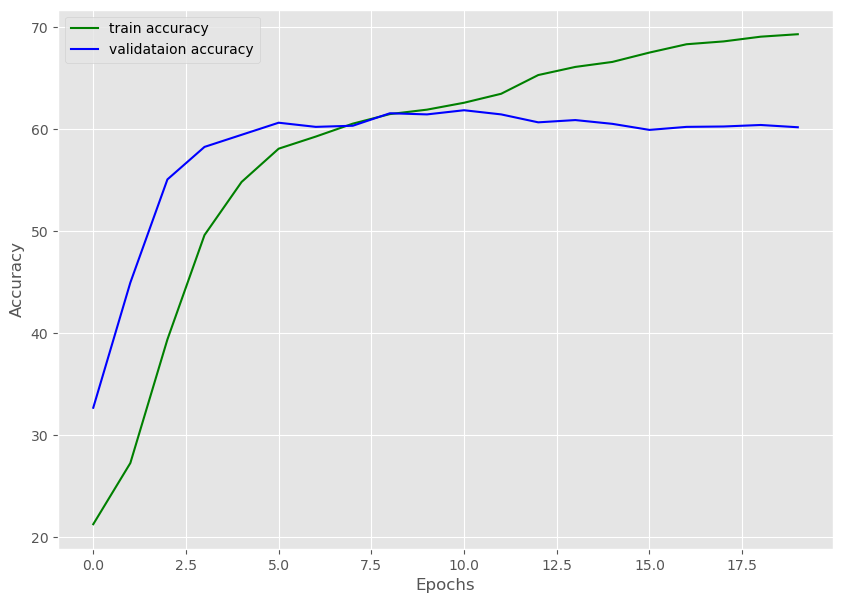

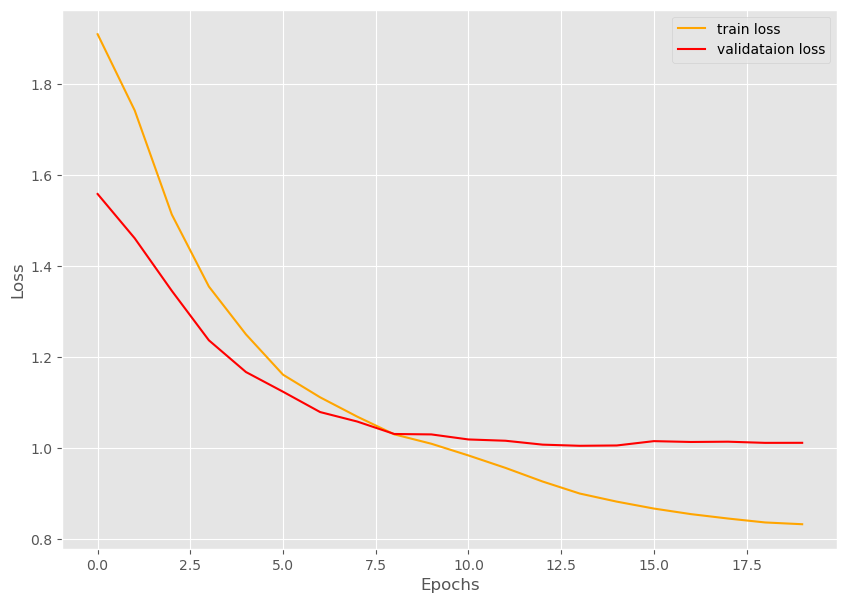

In [42]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(epochs):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    # save the best model till now if we have the least loss in the current epoch
    save_best_model(
        valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [43]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_cnn(5).to(device)
best_model_cp = torch.load('/kaggle/working/Stage0_28/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

Best model was saved at 14 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/2696 [00:00<?, ?it/s]

Accuracy : 60.90504451038575
UAR : 0.33470735664855156
f1_score_weighted : 0.5691704631886466
f1_score_macro : 0.33371487649954085


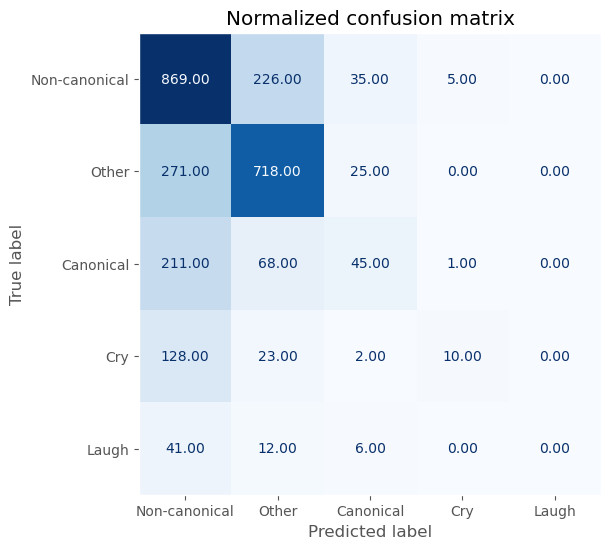

<Figure size 640x480 with 0 Axes>

In [44]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(5):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)

UAR = sum(class_recall) / 5
print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Non-canonical', 'Other', 'Canonical', 'Cry', 'Laugh']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Cry', 2: 'Laugh', 3:'Non_canonical', 4:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat_img_data_inf_junk_ens_28')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

In [45]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [46]:
mdl_path = Path('Stage0_224')
mdl_path.mkdir(exist_ok=True)

In [47]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
model = build_model_res(pretrained=False, fine_tune=True, num_classes=5).to(device).apply(iw)
print(model)
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/169 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 1.514, training acc: 39.223
Validation loss: 1.330, validation acc: 48.591

Best validation loss: 1.329647450937229

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.346, training acc: 93.109
Validation loss: 1.015, validation acc: 64.169
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/169 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 0.303, training acc: 95.233
Validation loss: 1.025, validation acc: 63.205
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


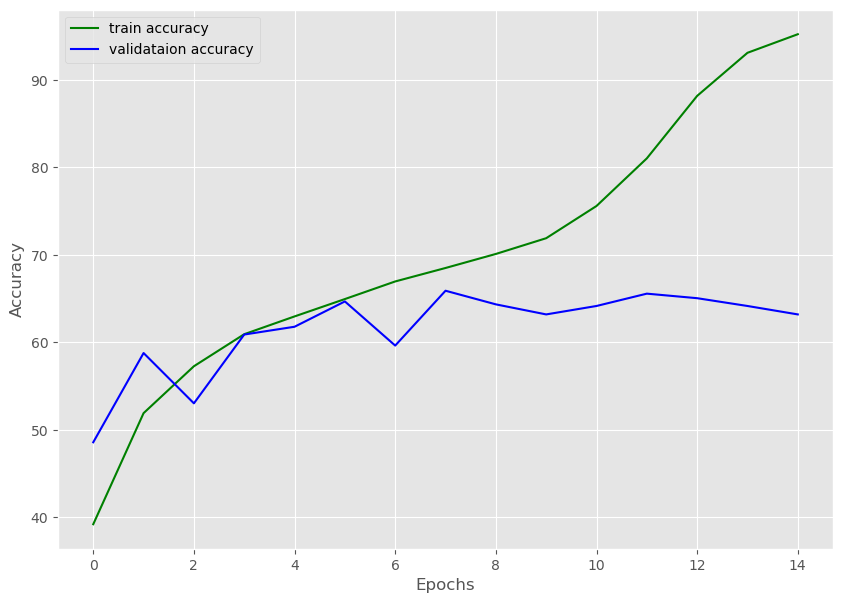

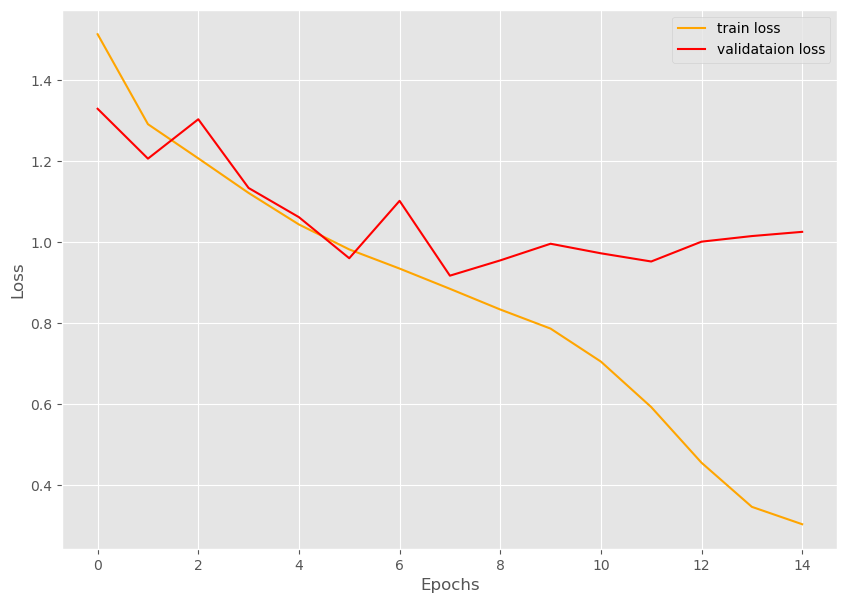

In [48]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(epochs):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    # save the best model till now if we have the least loss in the current epoch
    save_best_model(
        valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [49]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_res(pretrained=False, fine_tune=True, num_classes=5).to(device)
best_model_cp = torch.load('/kaggle/working/Stage0_224/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

[INFO]: Not loading pre-trained weights


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[INFO]: Fine-tuning all layers...
Best model was saved at 8 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/2696 [00:00<?, ?it/s]

Accuracy : 65.91246290801188
UAR : 0.3872295829522599
f1_score_weighted : 0.6294270922067624
f1_score_macro : 0.39294753891097367


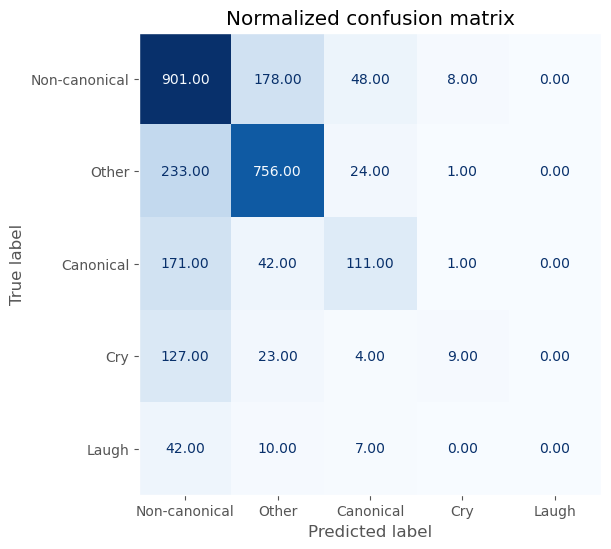

<Figure size 640x480 with 0 Axes>

In [50]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(5):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)

UAR = sum(class_recall) / 5
print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Non-canonical', 'Other', 'Canonical', 'Cry', 'Laugh']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Cry', 2: 'Laugh', 3:'Non_canonical', 4:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat_img_data_inf_junk_ens_28')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

# Stage1

In [189]:
img_data_Stage1_train = pd.concat([img_data_infant_CX.sample(n = 842), img_data_junk.sample(n = 842), img_data_infant_Cry_laugh])

img_data_Stage1_train['classes'] = img_data_Stage1_train['label'].map({'One':0, 'Two':1, 'Three':0, 'Four':2, 'Five':2}) # StrtoInt values infant voice and cry and laugh

img_data_Stage1_train.drop('label', axis =1, inplace = True)

img_data_Stage1_train.reset_index(inplace = True)

img_data_Stage1_train.drop('index', axis =1, inplace = True)

In [190]:
img_data_Stage1_valid = img_data_valid.copy()

img_data_Stage1_valid['classes'] = img_data_Stage1_valid['label'].map({'One':0, 'Two':1, 'Three':0, 'Four': 2, 'Five':2}) # StrtoInt values infant voice and cry and laugh

img_data_Stage1_valid.drop('label', axis =1, inplace = True)

img_data_Stage1_valid.reset_index(inplace = True)

img_data_Stage1_valid.drop('index', axis =1, inplace = True)

In [191]:
img_data_Stage1_train['classes'].value_counts(), img_data_Stage1_valid['classes'].value_counts()

(0    842
 1    842
 2    842
 Name: classes, dtype: int64,
 0    1460
 1    1014
 2     222
 Name: classes, dtype: int64)

In [170]:
valid_path = Path('valid_data')
valid_path.mkdir(exist_ok=True)

In [55]:
img_data_Stage1_valid.to_csv(valid_path/'img_data_stage1_valid.csv')

In [192]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage1_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 2526
})


In [193]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage1_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 2696
})


In [173]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [194]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [175]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [61]:
#! rm -rf {'img_data_inf_junk_crylaugh_0_28'}

In [176]:
mdl_path = Path('Stage1_28')
mdl_path.mkdir(exist_ok=True)

In [177]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage0_28/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes = 5)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=3).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model[-1].linear.weight.requires_grad = True
    model[-1].bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/40 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 1.458, training acc: 28.899
Validation loss: 1.157, validation acc: 23.220

Best validation loss: 1.1571263593762493

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.753, training acc: 68.369
Validation loss: 0.829, validation acc: 64.392
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/40 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 0.766, training acc: 67.538
Validation loss: 0.822, validation acc: 65.022
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


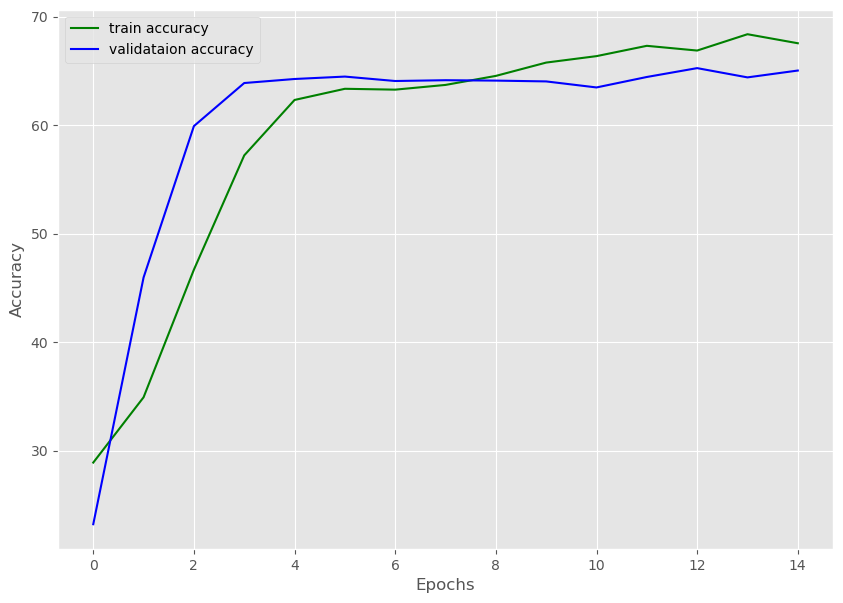

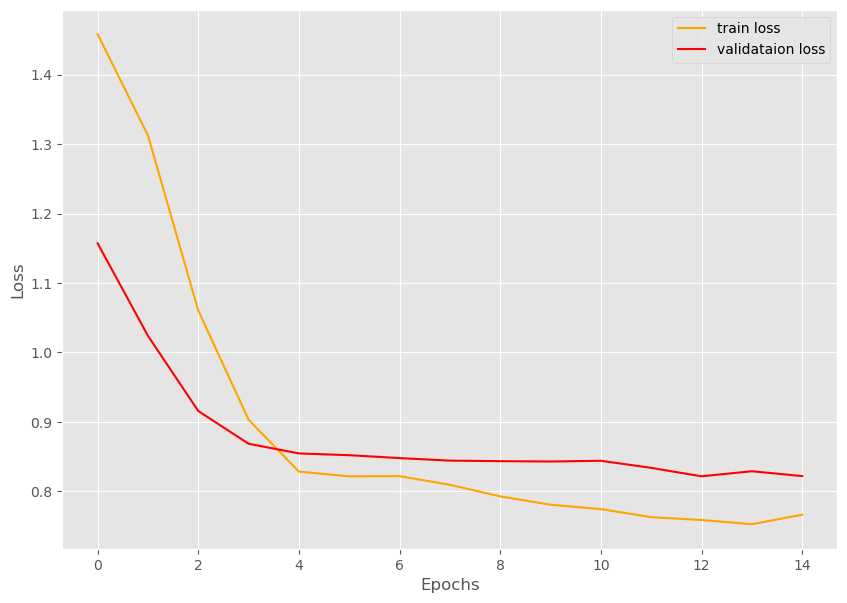

In [178]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [179]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_cnn(3).to(device)
best_model_cp = torch.load('/kaggle/working/Stage1_28/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

Best model was saved at 13 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/2696 [00:00<?, ?it/s]

Accuracy : 65.24480712166172
UAR : 0.6396166734944396
f1_score_weighted : 0.6678496481678239
f1_score_macro : 0.5873478336723836


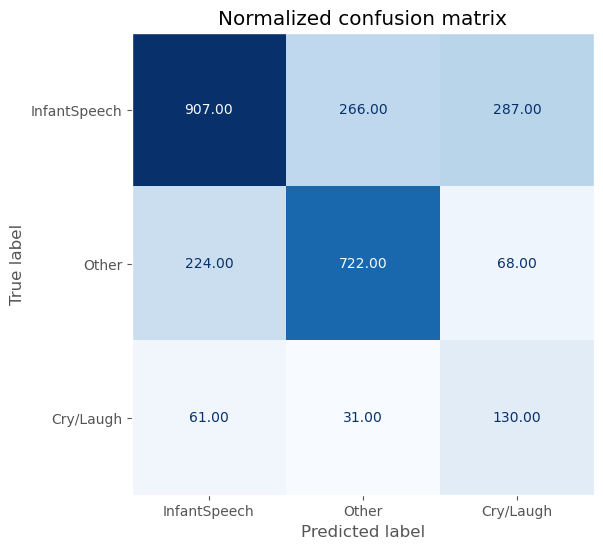

<Figure size 640x480 with 0 Axes>

In [180]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(3):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 3

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['InfantSpeech' , 'Other', 'Cry/Laugh']

# Define the mapping dictionary
mapping = {0:'Cry/Laugh', 1:'InfantSpeech', 2:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)


In [195]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [196]:
mdl_path = Path('Stage1_224')
mdl_path.mkdir(exist_ok=True)

In [197]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage0_224/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes=5, CNN = False)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=3, CNN = False).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model.fc.linear.weight.requires_grad = True
    model.fc.bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Freezing hidden layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/40 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 1.146, training acc: 42.953
Validation loss: 0.868, validation acc: 63.687

Best validation loss: 0.8680861373473434

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.426, training acc: 90.340
Validation loss: 0.770, validation acc: 66.766
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/40 [00:00<?, ?it/s]

Validation


  0%|          | 0/2696 [00:00<?, ?it/s]

Training loss: 0.384, training acc: 93.072
Validation loss: 0.801, validation acc: 65.616
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


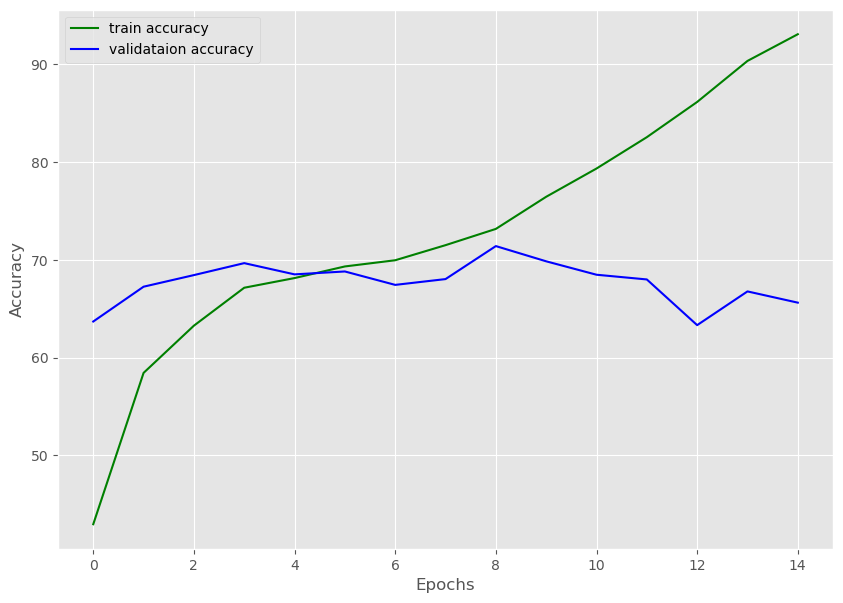

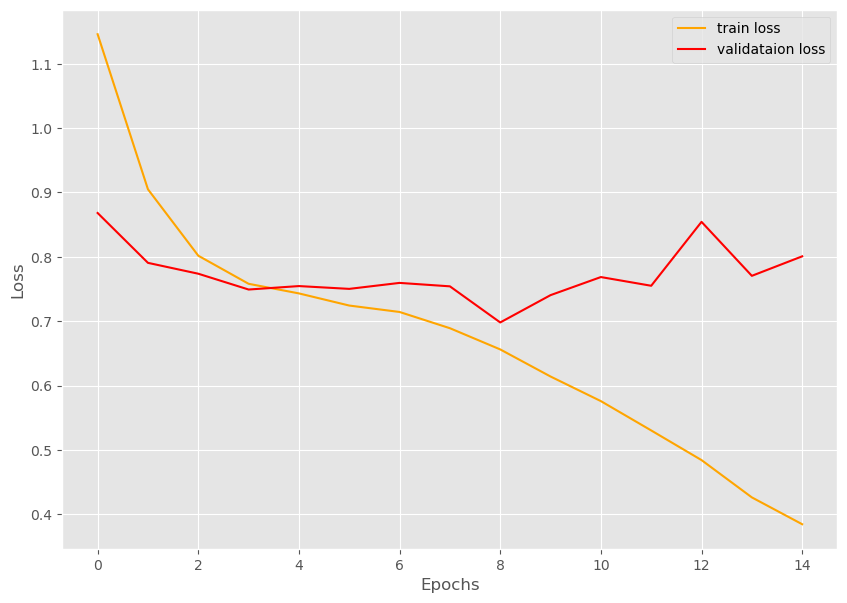

In [198]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [199]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_res(pretrained=False, fine_tune=True, num_classes=3).to(device)
best_model_cp = torch.load('/kaggle/working/Stage1_224/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Best model was saved at 9 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/2696 [00:00<?, ?it/s]

Accuracy : 71.4020771513353
UAR : 0.651274128144518
f1_score_weighted : 0.7190067098428657
f1_score_macro : 0.6305648798085857


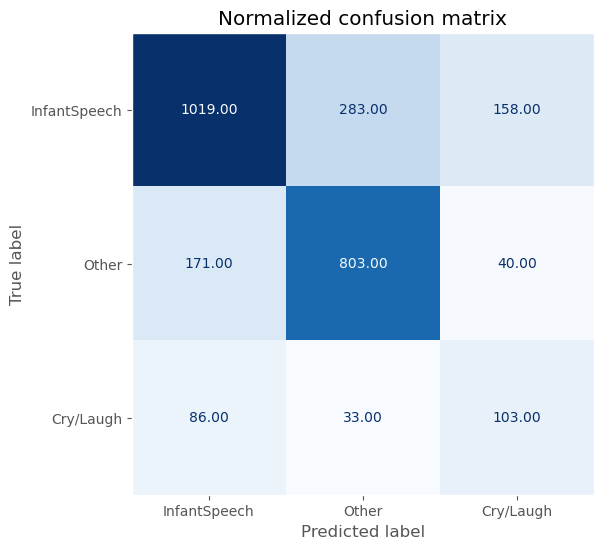

<Figure size 640x480 with 0 Axes>

In [200]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(3):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 3

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['InfantSpeech' , 'Other', 'Cry/Laugh']

# Define the mapping dictionary
mapping = {0:'Cry/Laugh', 1:'InfantSpeech', 2:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)


# Stage2

In [73]:
img_data_Stage2_train = pd.concat([img_data_infant_CX.sample(n = 842), img_data_infant_Cry_laugh])

img_data_Stage2_train['classes'] = img_data_Stage2_train['label'].map({'One':0, 'Three':0, 'Four':1, 'Five':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage2_train.drop('label', axis =1, inplace = True)

img_data_Stage2_train.reset_index(inplace = True)

img_data_Stage2_train.drop('index', axis =1, inplace = True)

In [74]:
img_data_Stage2_valid = pd.concat([img_data_infant_CX_valid, img_data_infant_Cry_laugh_valid])

img_data_Stage2_valid['classes'] = img_data_Stage2_valid['label'].map({'One':0, 'Three':0, 'Four': 1, 'Five':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage2_valid.drop('label', axis =1, inplace = True)

img_data_Stage2_valid.reset_index(inplace = True)

img_data_Stage2_valid.drop('index', axis =1, inplace = True)

In [75]:
img_data_Stage2_train['classes'].value_counts(), img_data_Stage2_valid['classes'].value_counts()

(0    842
 1    842
 Name: classes, dtype: int64,
 0    1460
 1     222
 Name: classes, dtype: int64)

In [76]:
valid_path = Path('valid_data')
valid_path.mkdir(exist_ok=True)

In [77]:
img_data_Stage2_valid.to_csv(valid_path/'img_data_stage2_valid.csv')

In [78]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage2_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 1684
})


In [79]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage2_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 1682
})


In [80]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [81]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [82]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [83]:
mdl_path = Path('Stage2_28')
mdl_path.mkdir(exist_ok=True)

In [85]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage1_28/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes = 3)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model[-1].linear.weight.requires_grad = True
    model[-1].bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()


Computation device: cuda

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/27 [00:00<?, ?it/s]

Validation


  0%|          | 0/1682 [00:00<?, ?it/s]

Training loss: 0.733, training acc: 60.392
Validation loss: 0.646, validation acc: 69.738

Best validation loss: 0.6464380265261167

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.558, training acc: 71.200
Validation loss: 0.567, validation acc: 71.998
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/27 [00:00<?, ?it/s]

Validation


  0%|          | 0/1682 [00:00<?, ?it/s]

Training loss: 0.535, training acc: 74.169
Validation loss: 0.551, validation acc: 73.246
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


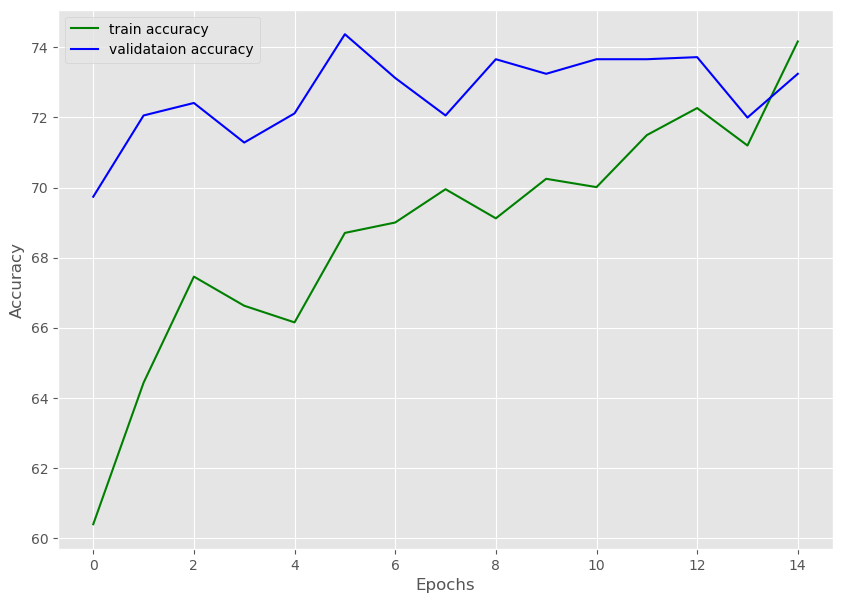

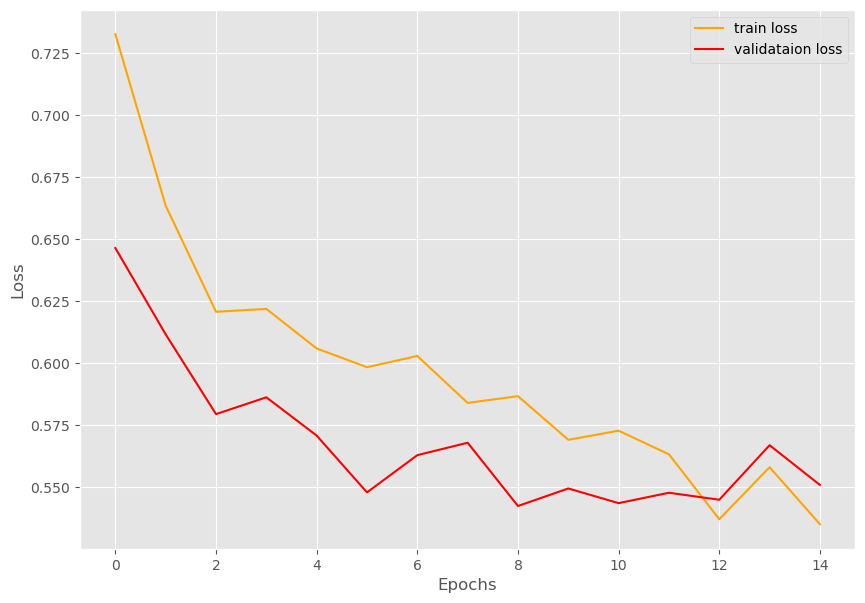

In [87]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [88]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_cnn(2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage2_28/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

Best model was saved at 9 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/1682 [00:00<?, ?it/s]

Accuracy : 73.66230677764565
UAR : 0.6993243243243243
f1_score_weighted : 0.7739714601167035
f1_score_macro : 0.612865851345882


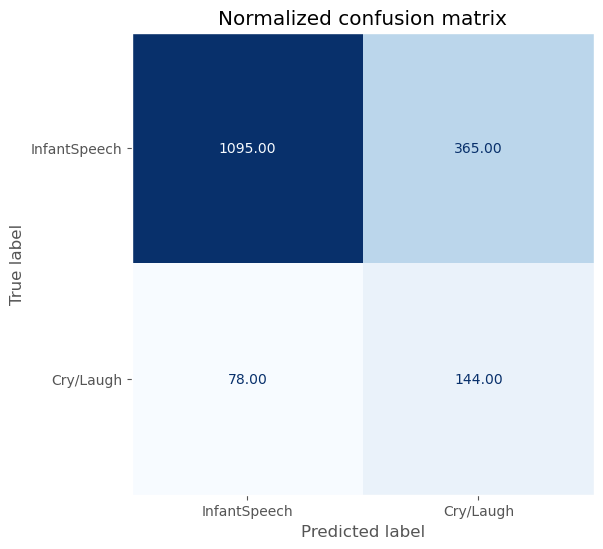

<Figure size 640x480 with 0 Axes>

In [89]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['InfantSpeech' , 'Cry/Laugh']

# Define the mapping dictionary
mapping = {0:'Cry/Laugh', 1:'InfantSpeech'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)


In [90]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [91]:
mdl_path = Path('Stage2_224')
mdl_path.mkdir(exist_ok=True)

In [92]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage1_224/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes=3, CNN = False)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2, CNN = False).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model.fc.linear.weight.requires_grad = True
    model.fc.bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Freezing hidden layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/27 [00:00<?, ?it/s]

Validation


  0%|          | 0/1682 [00:00<?, ?it/s]

Training loss: 0.804, training acc: 53.741
Validation loss: 0.726, validation acc: 59.037

Best validation loss: 0.7263815095747835

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.249, training acc: 94.893
Validation loss: 0.535, validation acc: 76.635
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/27 [00:00<?, ?it/s]

Validation


  0%|          | 0/1682 [00:00<?, ?it/s]

Training loss: 0.229, training acc: 96.971
Validation loss: 0.653, validation acc: 70.214
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


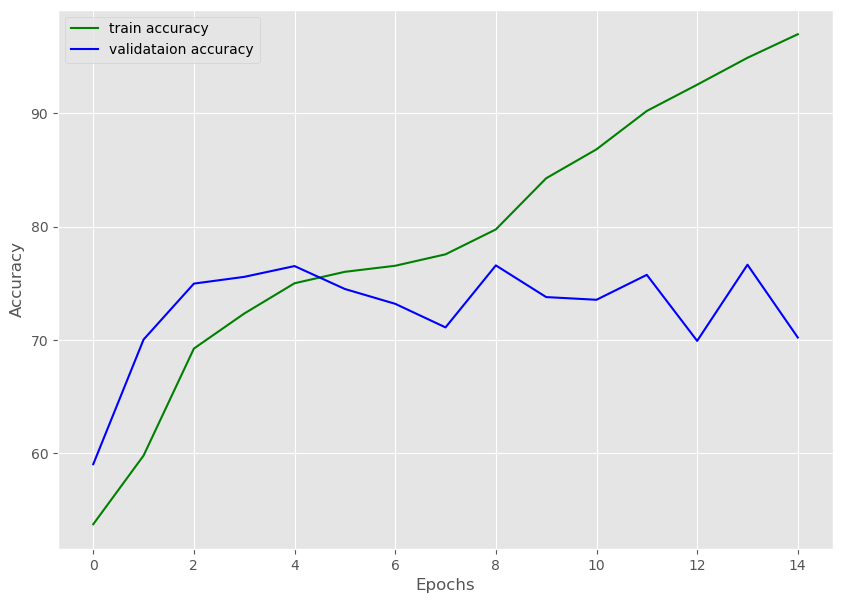

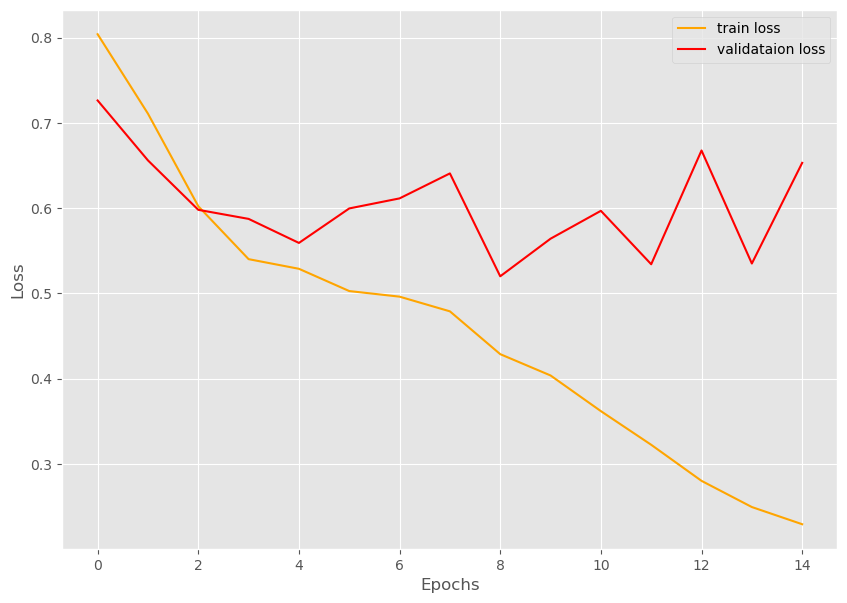

In [93]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [94]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage2_224/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Best model was saved at 9 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/1682 [00:00<?, ?it/s]

Accuracy : 76.57550535077289
UAR : 0.7065562137479946
f1_score_weighted : 0.7955733015123104
f1_score_macro : 0.6336654461190122


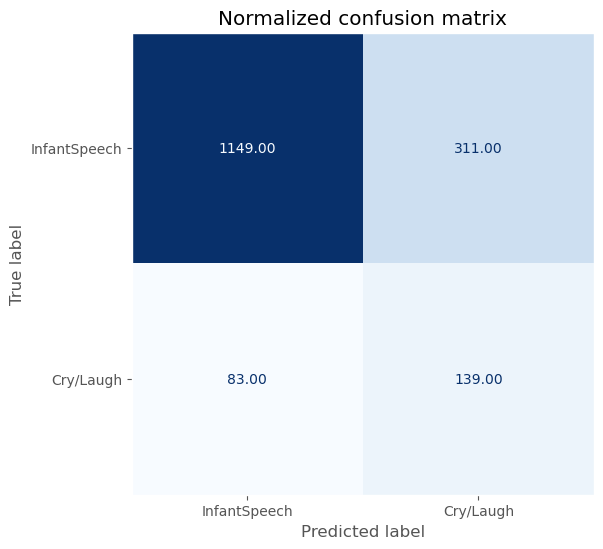

<Figure size 640x480 with 0 Axes>

In [95]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['InfantSpeech' , 'Cry/Laugh']

# Define the mapping dictionary
mapping = {0:'Cry/LaughInfantSpeech', 1:'InfantSpeech'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

# Stage 3

In [96]:
img_data_Stage3_train = pd.concat([img_data_infant_X.sample(n = 1501), img_data_infant_C])

img_data_Stage3_train['classes'] = img_data_Stage3_train['label'].map({'One':0, 'Three':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage3_train.drop('label', axis =1, inplace = True)

img_data_Stage3_train.reset_index(inplace = True)

img_data_Stage3_train.drop('index', axis =1, inplace = True)

In [97]:
img_data_Stage3_valid = pd.concat([img_data_infant_X_valid, img_data_infant_C_valid])

img_data_Stage3_valid['classes'] = img_data_Stage3_valid['label'].map({'One':0, 'Three':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage3_valid.drop('label', axis =1, inplace = True)

img_data_Stage3_valid.reset_index(inplace = True)

img_data_Stage3_valid.drop('index', axis =1, inplace = True)

In [98]:
valid_path = Path('valid_data')
valid_path.mkdir(exist_ok=True)

In [99]:
img_data_Stage3_valid.to_csv(valid_path/'img_data_stage3_valid.csv')

In [100]:
img_data_Stage3_train['classes'].value_counts(), img_data_Stage3_valid['classes'].value_counts()

(0    1501
 1    1501
 Name: classes, dtype: int64,
 0    1135
 1     325
 Name: classes, dtype: int64)

In [101]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage3_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 3002
})


In [102]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage3_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 1460
})


In [103]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [104]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [105]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [106]:
mdl_path = Path('Stage3_28')
mdl_path.mkdir(exist_ok=True)

In [107]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage2_28/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes = 2)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model[-1].linear.weight.requires_grad = True
    model[-1].bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/47 [00:00<?, ?it/s]

Validation


  0%|          | 0/1460 [00:00<?, ?it/s]

Training loss: 0.848, training acc: 54.364
Validation loss: 0.705, validation acc: 52.877

Best validation loss: 0.7054330277626645

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.523, training acc: 73.118
Validation loss: 0.626, validation acc: 66.096
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/47 [00:00<?, ?it/s]

Validation


  0%|          | 0/1460 [00:00<?, ?it/s]

Training loss: 0.526, training acc: 72.785
Validation loss: 0.625, validation acc: 66.507
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


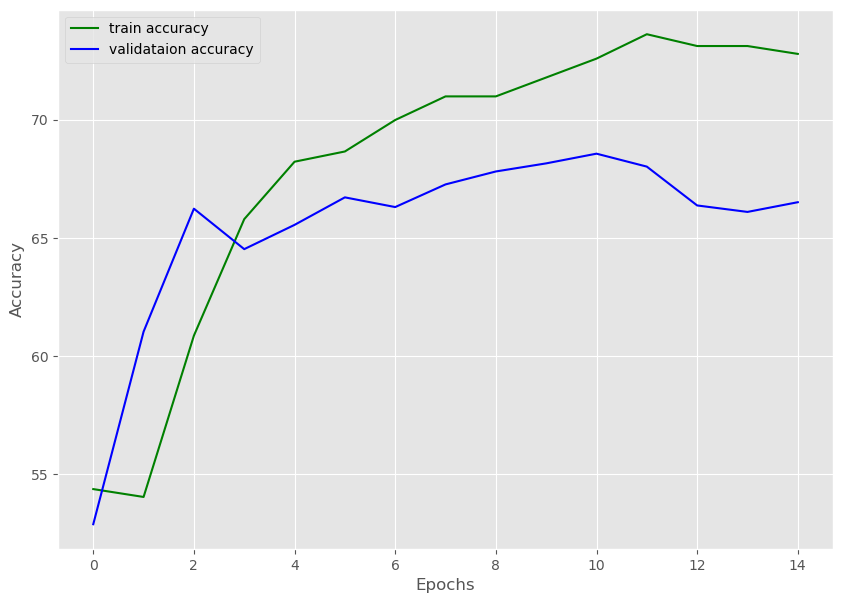

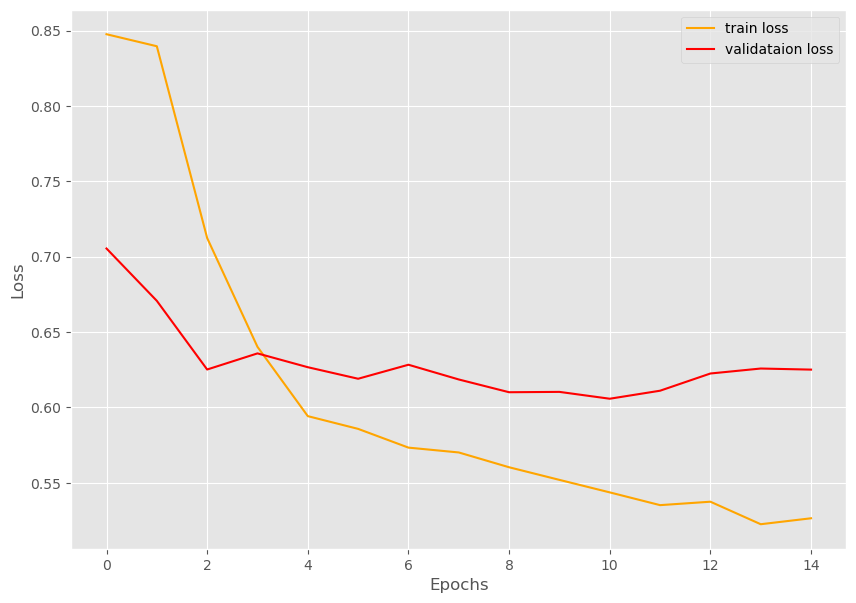

In [108]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [109]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_cnn(2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage3_28/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

Best model was saved at 11 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/1460 [00:00<?, ?it/s]

Accuracy : 68.56164383561644
UAR : 0.6572619451033548
f1_score_weighted : 0.707587702785198
f1_score_macro : 0.6199191107284628


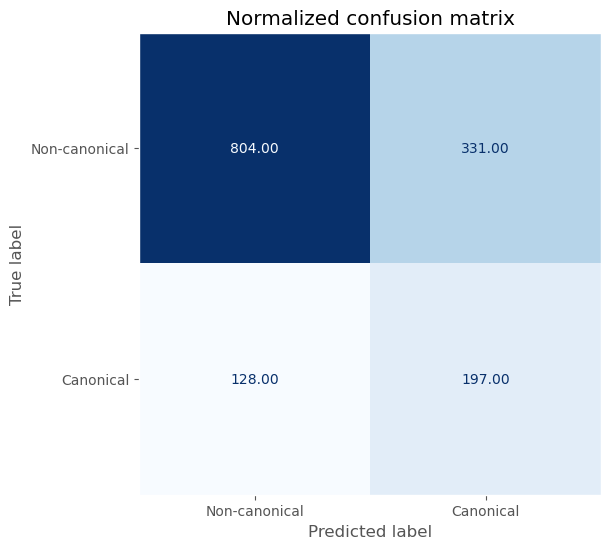

<Figure size 640x480 with 0 Axes>

In [110]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Non-canonical' , 'Canonical']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Non-canonical'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

In [111]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [112]:
mdl_path = Path('Stage3_224')
mdl_path.mkdir(exist_ok=True)

In [113]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage2_224/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes=2, CNN = False)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2, CNN = False).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model.fc.linear.weight.requires_grad = True
    model.fc.bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Freezing hidden layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/47 [00:00<?, ?it/s]

Validation


  0%|          | 0/1460 [00:00<?, ?it/s]

Training loss: 0.794, training acc: 54.863
Validation loss: 0.630, validation acc: 68.904

Best validation loss: 0.6300096104100142

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.203, training acc: 98.001
Validation loss: 0.522, validation acc: 74.452
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/47 [00:00<?, ?it/s]

Validation


  0%|          | 0/1460 [00:00<?, ?it/s]

Training loss: 0.184, training acc: 99.101
Validation loss: 0.548, validation acc: 71.781
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


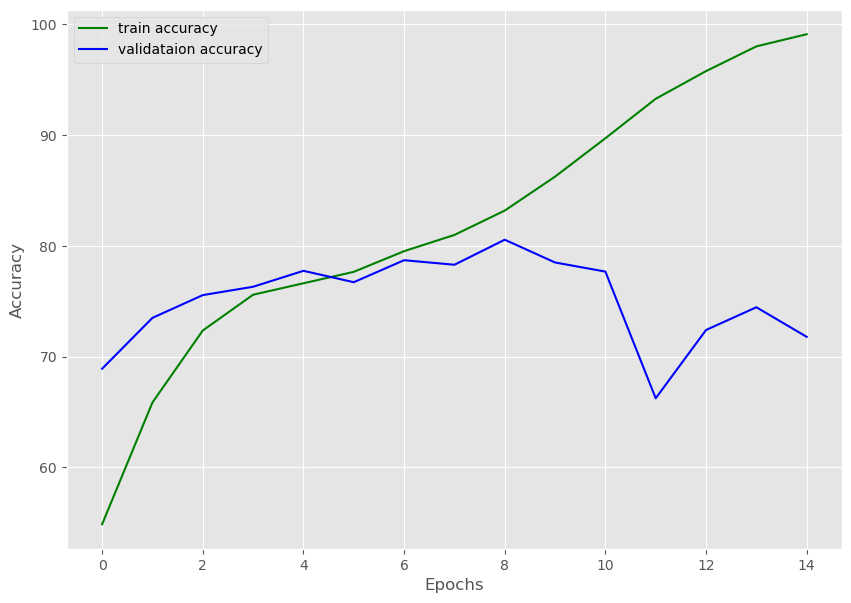

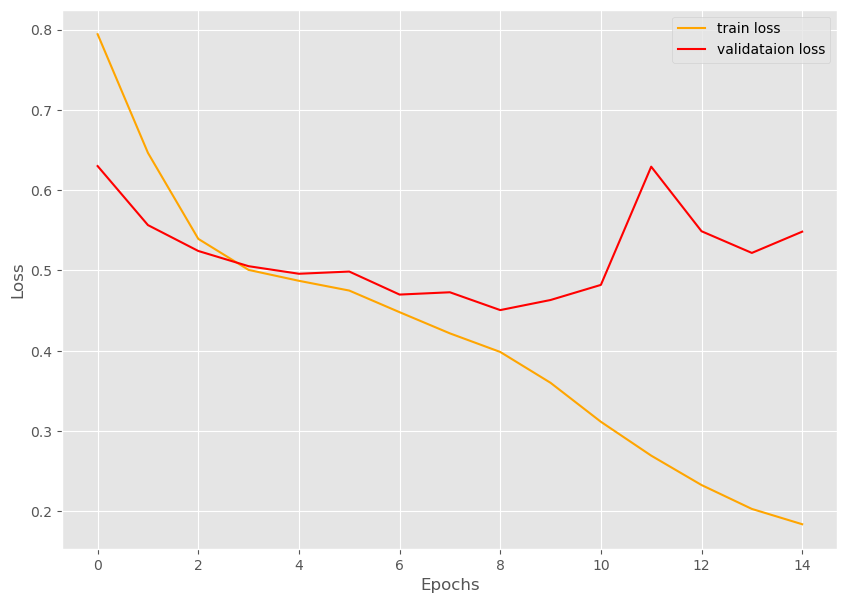

In [114]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [115]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage3_224/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Best model was saved at 9 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/1460 [00:00<?, ?it/s]

Accuracy : 80.54794520547945
UAR : 0.7398441206370722
f1_score_weighted : 0.8091955209121916
f1_score_macro : 0.7299845794782029


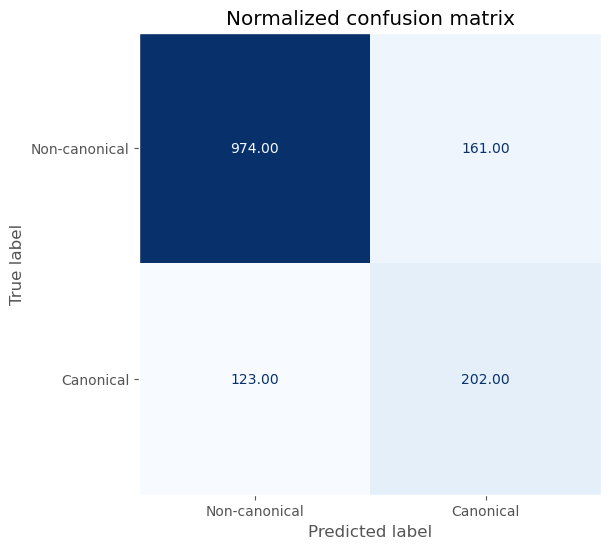

<Figure size 640x480 with 0 Axes>

In [116]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Non-canonical' , 'Canonical']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Non-canonical'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

# Stage 4

In [117]:
img_data_Stage4_train = pd.concat([img_data_infant_Cry.sample(n = 182), img_data_infant_laugh])

img_data_Stage4_train['classes'] = img_data_Stage4_train['label'].map({'Four':0, 'Five':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage4_train.drop('label', axis =1, inplace = True)

img_data_Stage4_train.reset_index(inplace = True)

img_data_Stage4_train.drop('index', axis =1, inplace = True)

In [118]:
img_data_Stage4_valid = pd.concat([img_data_infant_Cry_valid, img_data_infant_laugh_valid])

img_data_Stage4_valid['classes'] = img_data_Stage4_valid['label'].map({'Four':0, 'Five':1}) # StrtoInt values infant voice and cry and laugh

img_data_Stage4_valid.drop('label', axis =1, inplace = True)

img_data_Stage4_valid.reset_index(inplace = True)

img_data_Stage4_valid.drop('index', axis =1, inplace = True)

In [119]:
valid_path = Path('valid_data')
valid_path.mkdir(exist_ok=True)

In [120]:
img_data_Stage4_valid.to_csv(valid_path/'img_data_stage4_valid.csv')

In [121]:
img_data_Stage4_train['classes'].value_counts(), img_data_Stage4_valid['classes'].value_counts()

(0    182
 1    182
 Name: classes, dtype: int64,
 0    163
 1     59
 Name: classes, dtype: int64)

In [122]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage4_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 364
})


In [123]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage4_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 222
})


In [124]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [125]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [126]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [127]:
mdl_path = Path('Stage4_28')
mdl_path.mkdir(exist_ok=True)

In [128]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage2_28/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes = 2)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model[-1].linear.weight.requires_grad = True
    model[-1].bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/6 [00:00<?, ?it/s]

Validation


  0%|          | 0/222 [00:00<?, ?it/s]

Training loss: 0.894, training acc: 52.198
Validation loss: 0.804, validation acc: 35.135

Best validation loss: 0.8036473802886568

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.693, training acc: 60.440
Validation loss: 0.609, validation acc: 70.270

Best validation loss: 0.6087963982476844

Saving best model for epoch: 14

--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/6 [00:00<?, ?it/s]

Validation


  0%|          | 0/222 [00:00<?, ?it/s]

Training loss: 0.659, training acc: 64.835
Validation loss: 0.615, validation acc: 68.468
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


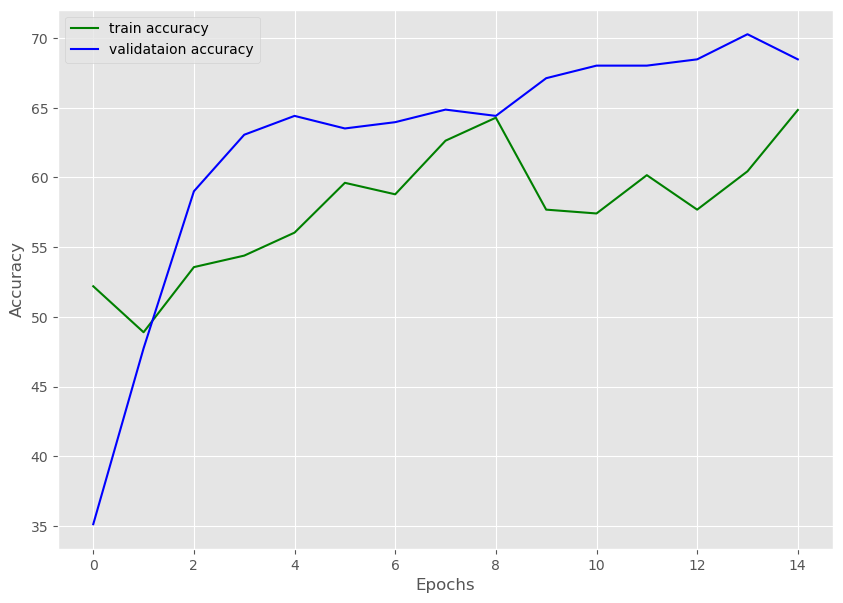

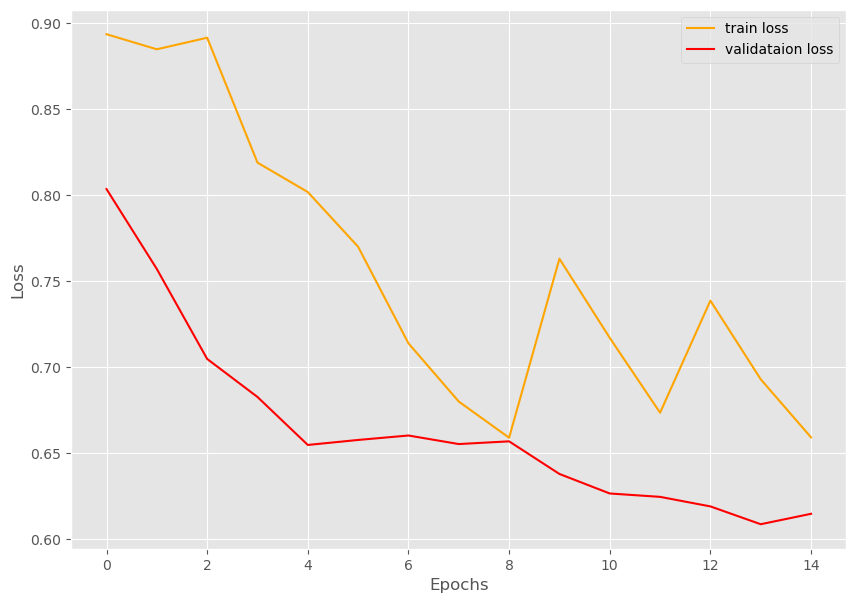

In [129]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [130]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_cnn(2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage4_28/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

Best model was saved at 14 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/222 [00:00<?, ?it/s]

Accuracy : 70.27027027027027
UAR : 0.6839970884891338
f1_score_weighted : 0.7160132803263108
f1_score_macro : 0.658334110624009


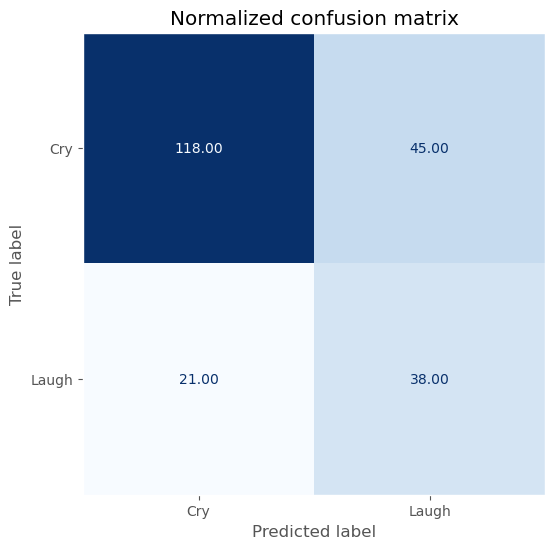

<Figure size 640x480 with 0 Axes>

In [131]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Cry' , 'Laugh']

# Define the mapping dictionary
mapping = {0:'Cry', 1:'Laugh'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

In [132]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [133]:
mdl_path = Path('Stage4_224')
mdl_path.mkdir(exist_ok=True)

In [134]:
# learning_parameters 
lr = 1e-3
epochs = 15
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# build the model
pretrained_model_path = '/kaggle/working/Stage3_224/best_model.pth'
model = load_pretrained_model(pretrained_model_path, n_classes=2, CNN = False)

# Replace last layers for three classes
model = replace_last_layers(model, n_classes=2, CNN = False).to(device)
print(model)
for param in model.parameters():
    param.requires_grad = False  # Freeze initial layers
    model.fc.linear.weight.requires_grad = True
    model.fc.bn.weight.requires_grad = True
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
# initialize SaveBestModel class
save_best_model = SaveBestModel()

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Freezing hidden layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

[INFO]: Epoch 1 of 15
Training


  0%|          | 0/6 [00:00<?, ?it/s]

Validation


  0%|          | 0/222 [00:00<?, ?it/s]

Training loss: 0.855, training acc: 52.747
Validation loss: 0.649, validation acc: 67.568

Best validation loss: 0.6490427866443857

Saving best model for epoch: 1

--------------------------------------------------
[INFO]: Epoch 2 of 15
Training


...

Training loss: 0.357, training acc: 87.912
Validation loss: 0.645, validation acc: 63.964
--------------------------------------------------
[INFO]: Epoch 15 of 15
Training


  0%|          | 0/6 [00:00<?, ?it/s]

Validation


  0%|          | 0/222 [00:00<?, ?it/s]

Training loss: 0.323, training acc: 89.011
Validation loss: 0.667, validation acc: 62.613
--------------------------------------------------
Saving final model...
TRAINING COMPLETE


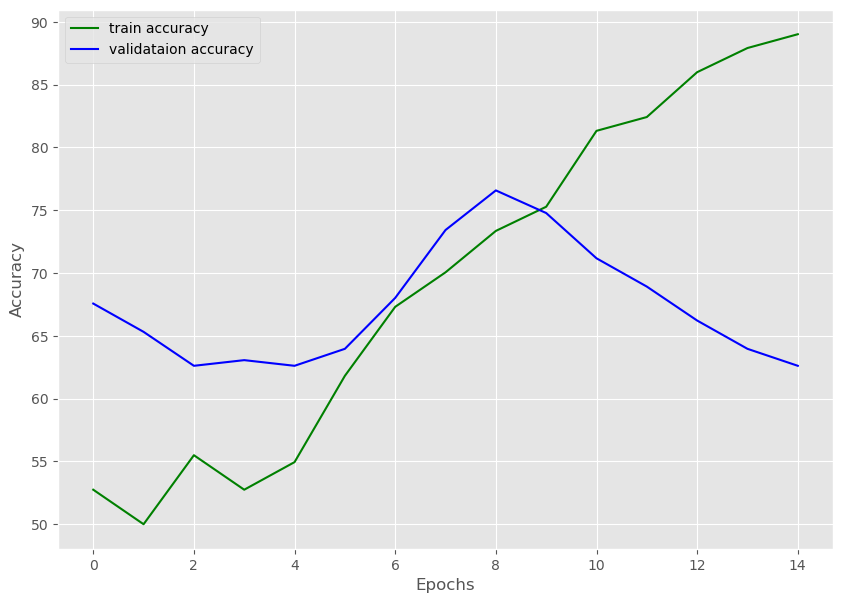

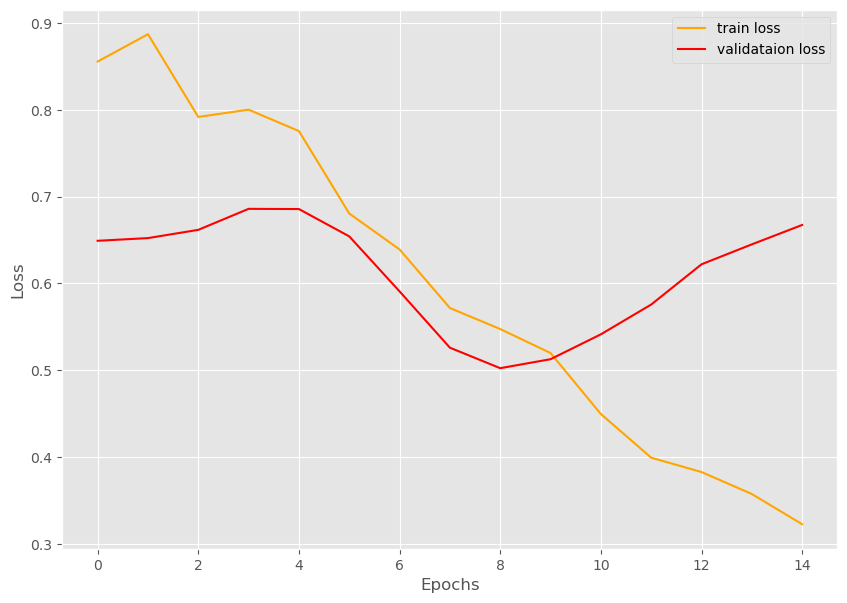

In [135]:
# lists to keep track of losses and accuracies
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []
# start the training
for epoch in range(5):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
for param in model.parameters():
    param.requires_grad = True  # Unfreeze all layers
# total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.\n")
# optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-4,
                                                steps_per_epoch=int(len(train_loader)),
                                                epochs=epochs,
                                                anneal_strategy='cos')
# loss function
criterion = nn.CrossEntropyLoss()
for epoch in range(5,15):
    print(f"[INFO]: Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_acc = train(model, train_loader, 
                                            optimizer, criterion, scheduler)
    valid_epoch_loss, valid_epoch_acc = validate(model, valid_loader,  
                                                criterion)
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    train_acc.append(train_epoch_acc)
    valid_acc.append(valid_epoch_acc)
    print(f"Training loss: {train_epoch_loss:.3f}, training acc: {train_epoch_acc:.3f}")
    print(f"Validation loss: {valid_epoch_loss:.3f}, validation acc: {valid_epoch_acc:.3f}")
    
    save_best_model(
    valid_epoch_loss, epoch, model, optimizer, criterion, mdl_path
    )
    print('-'*50)
    
# save the trained model weights for a final time
save_model(epochs, model, optimizer, criterion, mdl_path)
# save the loss and accuracy plots
save_plots(train_acc, valid_acc, train_loss, valid_loss, mdl_path)
print('TRAINING COMPLETE')

In [136]:
# computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

# load the best model checkpoint
model = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp = torch.load('/kaggle/working/Stage4_224/best_model.pth')
model.load_state_dict(best_model_cp['model_state_dict'])
best_model_epoch = best_model_cp['epoch']
print(f"Best model was saved at {best_model_epoch} epochs\n")

Computation device: cuda

[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Best model was saved at 9 epochs



Loading best epoch saved model weights...
Testing


  0%|          | 0/222 [00:00<?, ?it/s]

Accuracy : 76.57657657657657
UAR : 0.7323489653738172
f1_score_weighted : 0.7721007631835657
f1_score_macro : 0.7171974522292993


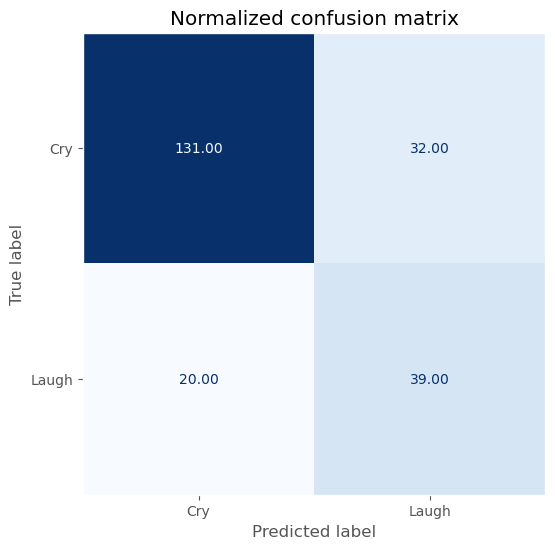

<Figure size 640x480 with 0 Axes>

In [137]:
acc, ap, at = test_best_model(model, best_model_cp, valid_loader)

print(f'Accuracy : {acc}')

at = np.array(at)

ap = np.array(ap)

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(2):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)
    
UAR = sum(class_recall) / 2

print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Cry' , 'Laugh']

# Define the mapping dictionary
mapping = {0:'Cry', 1:'Laugh'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)

In [159]:
import shutil

# Define the path to the working directory on Kaggle
kaggle_working_dir = '/kaggle/working/'

# Define the path to the destination ZIP file
zip_file_path = '/kaggle/working/kaggle_working_dir_11_08_2023.zip'

# Compress the entire working directory into a ZIP archive
shutil.make_archive(zip_file_path, 'zip', kaggle_working_dir)

# Move the ZIP archive to the output folder (optional)
#output_folder = '/kaggle/working/output/'
#shutil.move(zip_file_path + '.zip', output_folder + 'kaggle_working_dir.zip')

'/kaggle/working/kaggle_working_dir_11_08_2023.zip.zip'

In [181]:
model1 = build_model_cnn(3).to(device)
best_model_cp1 = torch.load('/kaggle/working/Stage1_28/best_model.pth')
model1.load_state_dict(best_model_cp1['model_state_dict'])

model2 = build_model_cnn(2).to(device)
best_model_cp2 = torch.load('/kaggle/working/Stage2_28/best_model.pth')
model2.load_state_dict(best_model_cp2['model_state_dict'])

model3 = build_model_cnn(2).to(device)
best_model_cp3 = torch.load('/kaggle/working/Stage3_28/best_model.pth')
model3.load_state_dict(best_model_cp3['model_state_dict'])

model4 = build_model_cnn(2).to(device)
best_model_cp4 = torch.load('/kaggle/working/Stage4_28/best_model.pth')
model4.load_state_dict(best_model_cp4['model_state_dict'])

<All keys matched successfully>

In [202]:
# Create a Dataset object from the df
dataset_train =  Dataset.from_pandas(img_data_Stage0_train)
# Print the dataset
print(dataset_train)

Dataset({
    features: ['image', 'classes'],
    num_rows: 10782
})


In [203]:
# Create a Dataset object from the df
dataset_valid =  Dataset.from_pandas(img_data_Stage0_valid)
# Print the dataset
print(dataset_valid)

Dataset({
    features: ['image', 'classes'],
    num_rows: 2696
})


In [184]:
tds28 = SpecImageGenerator28(dataset_train)
vds28 = SpecImageGenerator28(dataset_valid)

In [204]:
tds224 = SpecImageGenerator224(dataset_train)
vds224 = SpecImageGenerator224(dataset_valid)

In [186]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds28, vds28
)

In [187]:
#%%timeit
num_correct = 0 
num_examples = 0
all_predictions = []
all_targets = []
for batch in valid_loader:
    inputs, targets = batch[0], batch[1]
         
    inputs = inputs.to(device)
    model1.eval()
    cp1 = model1(inputs)
    targets = targets.to(device)
    all_targets.extend(targets.cpu().numpy().tolist())
    if torch.max(cp1, dim=1)[1] == 1: 
        all_predictions.append(1)
        
    else:
        model2.eval()
        cp2 = model2(inputs)
        if torch.max(cp2, dim=1)[1] == 0:
            model3.eval()
            cp3 = model3(inputs)
            if torch.max(cp3, dim=1)[1] == 1:
                all_predictions.append(2)
            else:
                all_predictions.append(0)
        else:
            model4.eval()
            cp4 = model4(inputs)
            if torch.max(cp4, dim=1)[1] == 1:
                all_predictions.append(4)
            else:
                all_predictions.append(3)  

2696 2696
accuracy : 0.546
UAR : 0.45331934908379423
f1_score_weighted : 0.5604290533779822
f1_score_macro : 0.41212613319897357


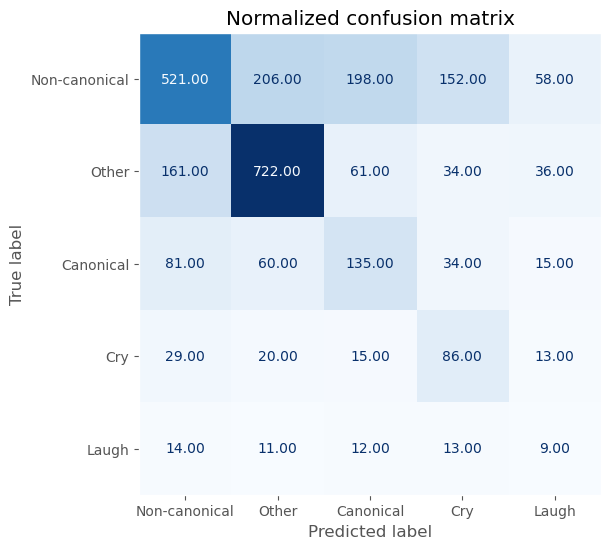

<Figure size 640x480 with 0 Axes>

In [188]:
print(len(all_predictions), len(all_targets))
ap = np.array(all_predictions)
at = np.array(all_targets)

accuracy = round((torch.tensor(ap)==torch.tensor(at)).float().mean().item(), 3)

print(f'accuracy : {accuracy}')

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(5):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)

UAR = sum(class_recall) / 5
print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

labels = ['Non-canonical', 'Other', 'Canonical', 'Cry', 'Laugh']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Cry', 2: 'Laugh', 3:'Non_canonical', 4:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat_img_data_inf_junk_ens_28')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)


In [201]:
model1Res = build_model_res(pretrained=False, fine_tune=True, num_classes=3).to(device)
best_model_cp1Res = torch.load('/kaggle/working/Stage1_224/best_model.pth')
model1Res.load_state_dict(best_model_cp1Res['model_state_dict'])

model2Res = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp2Res = torch.load('/kaggle/working/Stage2_224/best_model.pth')
model2Res.load_state_dict(best_model_cp2Res['model_state_dict'])

model3Res = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp3Res = torch.load('/kaggle/working/Stage3_224/best_model.pth')
model3Res.load_state_dict(best_model_cp3Res['model_state_dict'])

model4Res = build_model_res(pretrained=False, fine_tune=True, num_classes=2).to(device)
best_model_cp4Res = torch.load('/kaggle/working/Stage4_224/best_model.pth')
model4Res.load_state_dict(best_model_cp4Res['model_state_dict'])

[INFO]: Not loading pre-trained weights


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


[INFO]: Fine-tuning all layers...
[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...
[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...
[INFO]: Not loading pre-trained weights
[INFO]: Fine-tuning all layers...


<All keys matched successfully>

In [205]:
# get the training and validaion data loaders
train_loader, valid_loader = create_data_loaders(
    tds224, vds224
)

In [206]:
#%%timeit
num_correct = 0 
num_examples = 0
all_predictions = []
all_targets = []
for batch in valid_loader:
    inputs, targets = batch[0], batch[1]
         
    inputs = inputs.to(device)
    model1Res.eval()
    cp1 = model1Res(inputs)
    targets = targets.to(device)
    all_targets.extend(targets.cpu().numpy().tolist())
    if torch.max(cp1, dim=1)[1] == 1: 
        all_predictions.append(1)
        
    else:
        model2Res.eval()
        cp2 = model2Res(inputs)
        if torch.max(cp2, dim=1)[1] == 0:
            model3Res.eval()
            cp3 = model3Res(inputs)
            if torch.max(cp3, dim=1)[1] == 1:
                all_predictions.append(2)
            else:
                all_predictions.append(0)
        else:
            model4Res.eval()
            cp4 = model4Res(inputs)
            if torch.max(cp4, dim=1)[1] == 1:
                all_predictions.append(4)
            else:
                all_predictions.append(3)  

2696 2696
accuracy : 0.623
UAR : 0.5220543467156797
f1_score_weighted : 0.6282545069135338
f1_score_macro : 0.4888821800148956


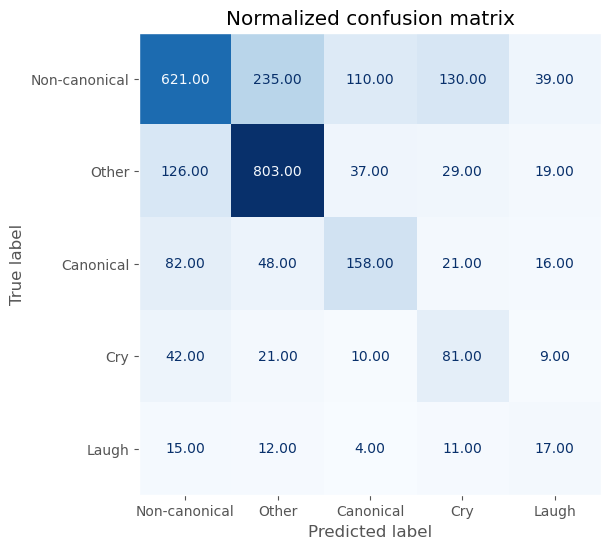

<Figure size 640x480 with 0 Axes>

In [207]:
print(len(all_predictions), len(all_targets))
ap = np.array(all_predictions)
at = np.array(all_targets)

accuracy = round((torch.tensor(ap)==torch.tensor(at)).float().mean().item(), 3)

print(f'accuracy : {accuracy}')

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
class_recall = []
for class_label in range(5):  # num_classes is the number of classes in your classification problem
    TP = ((at == class_label) & (ap == class_label)).sum()
    FN = ((at == class_label) & (ap != class_label)).sum()
    recall = TP / (TP + FN)
    class_recall.append(recall)

UAR = sum(class_recall) / 5
print(f'UAR : {UAR}')

f1 = f1_score(at, ap, average = 'weighted')
print(f'f1_score_weighted : {f1}')

f1 = f1_score(at, ap, average = 'macro')
print(f'f1_score_macro : {f1}')

#labels = ['InfantSpeech' , 'Other', 'Cry/Laugh']

# Define the mapping dictionary
#mapping = {0:'Cry/Laugh', 1:'InfantSpeech', 2:'Other'}

labels = ['Non-canonical', 'Other', 'Canonical', 'Cry', 'Laugh']

# Define the mapping dictionary
mapping = {0:'Canonical', 1:'Cry', 2: 'Laugh', 3:'Non_canonical', 4:'Other'}

# Map the actual values using the mapping dictionary
mapped_arr_at = np.vectorize(mapping.get)(np.array(at))

# Print the mapped array
#print(mapped_arr_at)

# Map the predicted values using the mapping dictionary
mapped_arr_ap = np.vectorize(mapping.get)(np.array(ap))

# Print the mapped array
#print(mapped_arr_ap1)

conf_path = Path('conf_mat_img_data_inf_junk_ens_28')
conf_path.mkdir(exist_ok=True)

plot_confusion_matrix(mapped_arr_at,mapped_arr_ap,labels, conf_path, normalize = None)